In [13]:
# !pip install pymupdf

In [14]:
import fitz  # PyMuPDF
import re
from collections import Counter

In [15]:
pdf_path = r"/home/thang_sinay/unlocode/data/draft_data/CUADERNILLO-VALENCIA-INGLES-1.1.pdf"
doc = fitz.open(pdf_path)

## extract waiting zone

In [16]:
keywords = [
    "anchorage area", "waiting zone", "anchorage zone",
    "zone d'attente", "zone de mouillage",
    "zona de fondeo", "zona de espera"
]

# Regex for coordinates (e.g., 39° 27,251 N 000° 14,804 W)
coord_pattern = r"\d{2,3}°\s*\d{1,2}[,.]\d{1,3}\s*[NS]\s*\d{3}°\s*\d{1,2}[,.]\d{1,3}\s*[EW]"

In [17]:
for page_num in range(len(doc)):
    page = doc.load_page(page_num)
    text = page.get_text()

    if any(keyword.lower() in text.lower() for keyword in keywords):
        print(f"\nPage {page_num + 1}: Anchorage Zone Detected")
        
        # Extract matching lines
        lines = text.split('\n')
        for line in lines:
            if any(keyword.lower() in line.lower() for keyword in keywords):
                print("Zone Description:", line.strip())
        
        # Extract coordinates
        coords = re.findall(coord_pattern, text)
        if coords:
            print("Coordinates Found:")
            for coord in coords:
                print("•", coord)


Page 4: Anchorage Zone Detected
Zone Description: Anchorage area
Zone Description: a) North anchorage area:
Zone Description: This North anchorage area has six anchorage points with a swinging circle up to 500 meters,
Coordinates Found:
• 39° 27,251 N 000° 14,804 W
• 39° 27,251 N 000° 12,714 W
• 39° 26,170 N 000° 12,714 W
• 39° 26,170 N 000° 14,804 W
• 39° 26,981 N 000° 14,456 W
• 39° 26,441 N 000° 14,456 W
• 39° 26,981 N 000° 13,759 W
• 39° 26,441 N 000° 13,759 W

Page 5: Anchorage Zone Detected
Zone Description: b)  South anchorage area:
Zone Description: This South anchorage area has twelve anchorage points with a swinging circle up to 400 meters,
Zone Description: In addition, the south anchorage area, has six anchorage points with a swinging circle up to 500
Coordinates Found:
• 39° 26,981 N 000° 13,062 W
• 39° 26,441 N 000° 13,062 W
• 39° 24,297 N 000° 17,029 W
• 39° 24,297 N 000° 12,714 W
• 39° 23,000 N 000° 12,714 W
• 39° 23,000 N 000° 17,029 W
• 39° 24,081 N 000° 16,751 W
• 3

## apply NLP

remember to download pretrained model

In [18]:
# !python -m spacy download en_core_web_sm
# !python -m spacy download fr_core_news_sm
# !python -m spacy download es_core_news_sm

In [19]:
import spacy
# nlp = spacy.load("en_core_web_sm")
nlp = spacy.load("es_core_news_sm")
# nlp = spacy.load("fr_core_news_sm")

In [20]:

# pdf_path = r"/home/thang_sinay/unlocode/data/draft_data/CUADERNILLO-VALENCIA-INGLES-1.1.pdf"
pdf_path = r"/home/thang_sinay/unlocode/data/draft_data/07_PO_ACCESSOS_ES.pdf"
# pdf_path = r"/home/thang_sinay/unlocode/data/draft_data/guide_du_port_du_havre.pdf"

In [21]:
doc = fitz.open(pdf_path)
for page_num in range(len(doc)):
    text = doc[page_num].get_text()

    # Search for keyword matches
    for keyword in keywords:
        if keyword.lower() in text.lower():
            print(f"\n Page {page_num+1} — Found keyword: {keyword}")

            # Get surrounding context (paragraphs)
            paragraphs = text.split("\n\n")
            for para in paragraphs:
                if keyword.lower() in para.lower():
                    print(" Context paragraph:")
                    print(para.strip())

                    # Run NLP to detect named entities
                    doc_nlp = nlp(para)
                    for ent in doc_nlp.ents:
                        if ent.label_ in ["GPE", "LOC"]:  # Geo-political entity or location
                            print(f" Location detected: {ent.text}")

                    # Extract coordinates
                    coords = re.findall(coord_pattern, para)
                    for c in coords:
                        print(f" Coordinate: {c}")


 Page 1 — Found keyword: zona de fondeo
 Context paragraph:
Ordenación del tráfico marítimo en los accesos al Puerto de Barcelona. Documento aprobado por el Consejo de 
Administración en fecha 19 de julio de 2006. 
 
 
1 
ORDENACIÓN DEL TRÁFICO MARÍTIMO EN LOS ACCESOS AL PUERTO DE BARCELONA. 
 
Organización del tráfico de entrada y salida del Puerto de Barcelona.- 
 
Se establece como sistema de organización del tráfico marítimo en el puerto de Barcelona 
dos can ales de acceso, la "canal de acceso Sur" y la "canal de acceso Norte", con sendos 
dispositivos de separación al objeto de conducir a través de ellos e l tráfico que recale o 
salga de las dos bocanas del Puerto de Barcelona, logrando con ello dos objetivos 
preferentes, evitar, por un lado, que los buques crucen la zona de fondeo y, por otro, alejar 
el área de espera y/o recalada de las inmediaciones de la bocana, reduciendo de esta 
manera los riesgos de las situaciones de cruce o vuelta encontrada. 
 
En ambas canales el 

## Extract image

In [22]:
# !pip install pytesseract
# !pip install pillow
# !pip install pdf2image

In [23]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mping

In [24]:
pdf_path = r"/home/thang_sinay/unlocode/data/draft_data/publicacin4.pdf"
output_dir = r"/home/thang_sinay/unlocode/data/draft_data"
os.makedirs(output_dir, exist_ok=True)

doc = fitz.open(pdf_path)

image_count = 0

In [25]:
for page_index in range(len(doc)):
    page = doc[page_index]
    images = page.get_images(full=True)

    for img_index, img in enumerate(images):
        xref = img[0]
        base_image = doc.extract_image(xref)
        image_bytes = base_image["image"]
        image_ext = base_image["ext"]
        image_filename = f"page{page_index+1}_img{img_index+1}.{image_ext}"

        with open(os.path.join(output_dir, image_filename), "wb") as f:
            f.write(image_bytes)

        image_count += 1

print(f"Extracted {image_count} images to '{output_dir}'")

Extracted 3 images to '/home/thang_sinay/unlocode/data/draft_data'


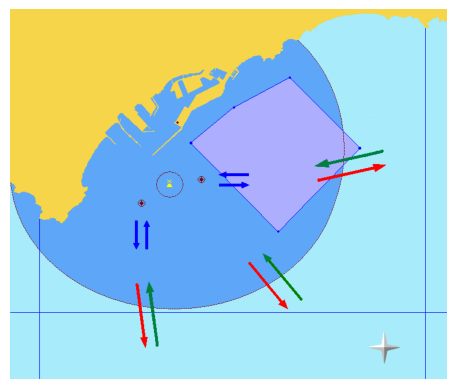

In [26]:
img_path = r"/home/thang_sinay/unlocode/data/draft_data/page1_img1.png"
img = mping.imread(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()